<a href="https://colab.research.google.com/github/Ramyan-Iz/KAA/blob/main/DeBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
# Загрузка Excel-файла
df = pd.read_excel('VIBOR.xlsx', header=None, names=['raw_data'])  # Читаем как одну колонку
print(df.head())
# Разделяем по последней запятой
df[['text', 'label']] = df['raw_data'].str.rsplit(',', n=1, expand=True)

# Удаляем лишние пробелы
df['text'] = df['text'].str.strip()
df['label'] = df['label'].str.strip().astype(float)  # Преобразуем в число

df = df[df['label'] != 7.0].copy()
# Проверяем результат
print(df.head())
print(f"Всего строк: {len(df)}")
print(f"Распределение классов:\n{df['label'].value_counts()}")
print(f"Есть ли пропуски:\n{df.isnull().sum()}")

                                            raw_data
0  I cannot believe I ate that cake. This overwhe...
1  man cannot swear i ate that stuff. The shame b...
2  I found Jason s observation very helpful in re...
3  i found jason s observation very helpful in re...
4  I feel so useless and do not know how to trust...
                                            raw_data  \
0  I cannot believe I ate that cake. This overwhe...   
1  man cannot swear i ate that stuff. The shame b...   
2  I found Jason s observation very helpful in re...   
3  i found jason s observation very helpful in re...   
4  I feel so useless and do not know how to trust...   

                                                text  label  
0  I cannot believe I ate that cake. This overwhe...    2.0  
1  man cannot swear i ate that stuff. The shame b...    2.0  
2  I found Jason s observation very helpful in re...    2.0  
3  i found jason s observation very helpful in re...    2.0  
4  I feel so useless and do not kno


Loaded data summary:
                                            raw_data  \
0  I cannot believe I ate that cake. This overwhe...   
1  man cannot swear i ate that stuff. The shame b...   
2  I found Jason s observation very helpful in re...   
3  i found jason s observation very helpful in re...   
4  I feel so useless and do not know how to trust...   

                                                text  label  
0  I cannot believe I ate that cake. This overwhe...    2.0  
1  man cannot swear i ate that stuff. The shame b...    2.0  
2  I found Jason s observation very helpful in re...    2.0  
3  i found jason s observation very helpful in re...    2.0  
4  I feel so useless and do not know how to trust...    2.0  

Total rows: 60274

Class distribution:
label
0.0    14001
4.0    12188
2.0     9196
1.0     7896
3.0     7539
5.0     5176
6.0     4278
Name: count, dtype: int64

Missing values:
raw_data    0
text        0
label       0
dtype: int64
COGNITIVE BIAS DATASET CHECK (ENGL

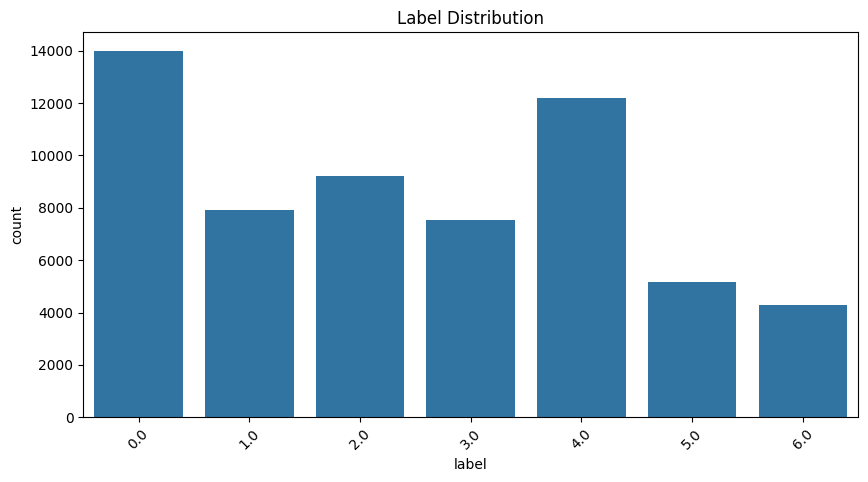


Label counts:
label
0.0    14001
1.0     7896
2.0     9196
3.0     7539
4.0    12188
5.0     5176
6.0     4278
Name: count, dtype: int64
3. TEXT ANALYSIS:

Text length statistics:
count    60274.000000
mean       150.934997
std         61.683465
min         22.000000
25%        109.000000
50%        148.000000
75%        190.000000
max        693.000000
Name: text_length, dtype: float64


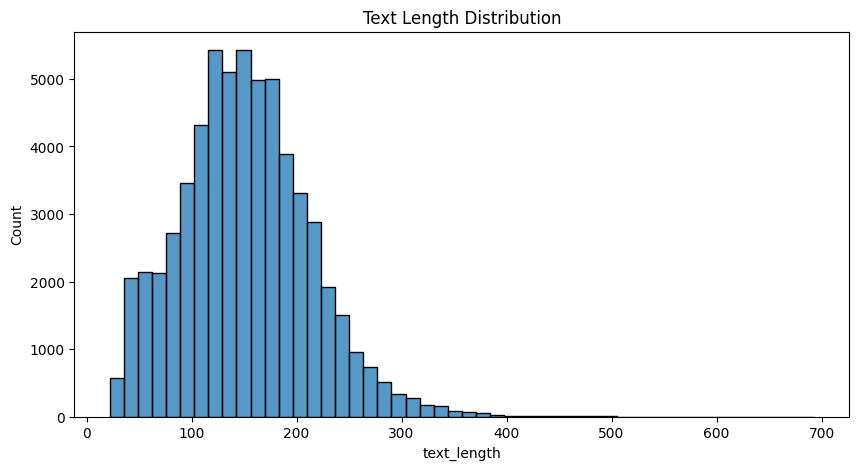

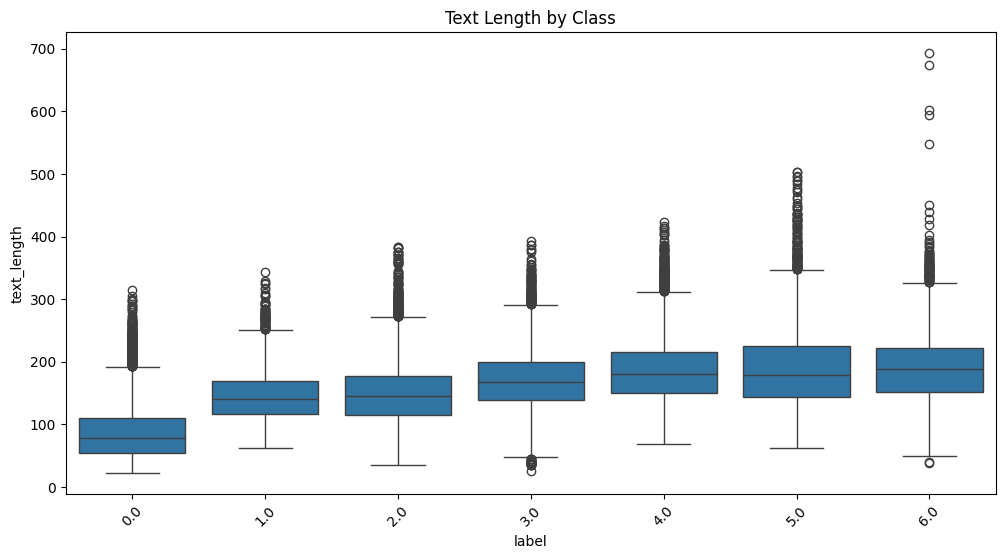


Text samples per class:

Label 0.0:
1. Just about to say goodbye to and two of the best intern that elevate have ever had....
2. Imperial later, I am ready ready for a nap....

Label 1.0:
1. whatever the rather sentimental short lesson about sexuality, persons in color come wearing in various colored tee - shirt at shower scene. I tend to ...
2. darn i wa s going to need to move myself to another whopping meal, except now he cannot because you need not pay. I blame myself for not being persuas...

Label 2.0:
1. I feel useless when I cannot fix such a simple problem myself.I feel frustrated and inadequate, believing I am incapable and helpless....
2. I felt better yesterday than I do today. The contrast deepens my disappointment, and my feelings make it hard to stay positive. It’s a fluctuating emo...

Label 3.0:
1. I just got home from school damn, I have so many assignment School is so life consuming. Overwhelmed by work makes me stressed. I hope to manage time ...
2. i kept feeling 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

def check_cognitive_bias_dataset(df, text_column='text', label_column='label'):
    """
    Проверяет датасет с когнитивными искажениями на английском языке

    Параметры:
    df - DataFrame с данными
    text_column - название столбца с текстом
    label_column - название столбца с метками
    """

    print("="*50)
    print("COGNITIVE BIAS DATASET CHECK (ENGLISH)")
    print("="*50 + "\n")

    # 1. Basic info
    print("1. BASIC DATASET INFO:")
    print(f"Total records: {len(df)}")
    print(f"Sample data:\n{df.head(3)}\n")
    print(f"Data types:\n{df.dtypes}\n")
    print(f"Missing values:\n{df.isnull().sum()}\n")

    # 2. Label analysis
    print("="*50)
    print("2. LABEL DISTRIBUTION:")
    unique_labels = df[label_column].unique()
    print(f"Unique labels: {sorted(unique_labels)}")

    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=label_column, order=sorted(unique_labels))
    plt.title("Label Distribution")
    plt.xticks(rotation=45)
    plt.show()

    label_dist = df[label_column].value_counts().sort_index()
    print("\nLabel counts:")
    print(label_dist)

    # Check for imbalance
    imbalance_ratio = label_dist.min() / label_dist.max()
    if imbalance_ratio < 0.3:
        print(f"\nWarning: Significant class imbalance (ratio {imbalance_ratio:.2f})")

    # 3. Text analysis
    print("="*50)
    print("3. TEXT ANALYSIS:")

    # Text length
    df['text_length'] = df[text_column].apply(len)
    print("\nText length statistics:")
    print(df['text_length'].describe())

    plt.figure(figsize=(10, 5))
    sns.histplot(df['text_length'], bins=50)
    plt.title("Text Length Distribution")
    plt.show()

    # Text length by class
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=label_column, y='text_length', order=sorted(unique_labels))
    plt.title("Text Length by Class")
    plt.xticks(rotation=45)
    plt.show()

    # Text samples per class
    print("\nText samples per class:")
    for label in sorted(unique_labels):
        sample_texts = df[df[label_column] == label][text_column].sample(min(2, len(df[df[label_column] == label])))
        print(f"\nLabel {label}:")
        for i, text in enumerate(sample_texts, 1):
            print(f"{i}. {text[:150]}...")

    # 4. Word analysis by class
    print("="*50)
    print("4. WORD FREQUENCY ANALYSIS:")

    for label in sorted(unique_labels):
        texts = df[df[label_column] == label][text_column]
        if len(texts) > 0:
            vectorizer = CountVectorizer(stop_words='english', max_features=15)  # Using English stop words
            X = vectorizer.fit_transform(texts)
            features = vectorizer.get_feature_names_out()

            print(f"\nTop 15 words for class {label}:")
            print(", ".join(features))

    # 5. Data leakage check
    print("="*50)
    print("5. DATA LEAKAGE CHECK:")

    possible_leakage = False
    for label in unique_labels:
        if str(label) in ['0', '1']:  # Checking for binary labels
            mask = df[text_column].str.contains(str(label), regex=False, case=False)
            if mask.any():
                print(f"Found {mask.sum()} texts containing label '{label}' in text")
                possible_leakage = True

    if not possible_leakage:
        print("No obvious data leakage detected")

    # 6. Recommendations
    print("="*50)
    print("6. RECOMMENDATIONS:")

    if len(df) < 1000:
        print("- Small dataset (<1000 records) - consider collecting more data")

    if imbalance_ratio < 0.3:
        print("- Significant class imbalance - use balancing techniques (oversampling/undersampling)")

    if df['text_length'].std() > 300:
        print("- Large variation in text lengths - consider normalizing text length")

    print("\n" + "="*50)
    print("ANALYSIS COMPLETE")

# Your data loading function remains the same
def load_and_prepare_data(filepath):
    df = pd.read_excel(filepath, header=None, names=['raw_data'])
    df[['text', 'label']] = df['raw_data'].str.rsplit(',', n=1, expand=True)
    df['text'] = df['text'].str.strip()
    df['label'] = df['label'].str.strip().astype(float)
    df = df[df['label'] != 7.0].copy()

    print("\nLoaded data summary:")
    print(df.head())
    print(f"\nTotal rows: {len(df)}")
    print(f"\nClass distribution:\n{df['label'].value_counts()}")
    print(f"\nMissing values:\n{df.isnull().sum()}")

    return df

# Usage
file_path = 'VIBOR.xlsx'
df = load_and_prepare_data(file_path)
check_cognitive_bias_dataset(df)

In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def validate_dataset(df, text_col='text', label_col='label'):
    """Проверяет валидность датасета и выявляет потенциальные проблемы"""

    print("="*50)
    print("DATA VALIDATION REPORT")
    print("="*50 + "\n")

    # 1. Проверка структуры данных
    print("1. STRUCTURE VALIDATION:")
    required_columns = {text_col, label_col}
    missing_cols = required_columns - set(df.columns)
    if missing_cols:
        print(f"❌ Error: Missing columns {missing_cols}")
    else:
        print("✅ All required columns present")

    # 2. Проверка пропущенных значений
    print("\n2. MISSING VALUES CHECK:")
    null_counts = df[[text_col, label_col]].isnull().sum()
    if null_counts.any():
        print(f"❌ Found null values:\n{null_counts}")
    else:
        print("✅ No missing values found")

    # 3. Проверка корректности меток
    print("\n3. LABEL VALIDATION:")
    valid_labels = {0.0, 1.0}  # Укажите ваши допустимые метки
    invalid_labels = set(df[label_col].unique()) - valid_labels
    if invalid_labels:
        print(f"❌ Invalid labels detected: {invalid_labels}")
    else:
        print(f"✅ All labels are valid: {valid_labels}")

    # 4. Проверка текстового содержимого
    print("\n4. TEXT CONTENT VALIDATION:")

    # Проверка пустых текстов
    empty_texts = df[text_col].str.strip().eq('')
    if empty_texts.any():
        print(f"❌ Found {empty_texts.sum()} empty texts")
    else:
        print("✅ No empty texts found")

    # Проверка на "мусорные" тексты (например, только спецсимволы)
    def is_garbage_text(text):
        no_letters = not any(c.isalpha() for c in text)
        mostly_specials = sum(not c.isalnum() and not c.isspace() for c in text) / len(text) > 0.7
        return no_letters or mostly_specials

    df['is_garbage'] = df[text_col].apply(is_garbage_text)
    if df['is_garbage'].any():
        print(f"❌ Found {df['is_garbage'].sum()} potentially garbage texts")
        print("Sample garbage texts:")
        for text in df[df['is_garbage']][text_col].head(3):
            print(f"- {text[:100]}...")
    else:
        print("✅ No garbage texts detected")

    # 5. Проверка на утечку данных
    print("\n5. DATA LEAKAGE CHECK:")
    leakage_found = False

    # Проверка наличия меток в тексте
    for label in df[label_col].unique():
        if str(label) in ['0', '1']:  # Проверяем для бинарных меток
            mask = df[text_col].str.contains(str(label), regex=False, case=False)
            if mask.any():
                print(f"❌ Found {mask.sum()} texts containing label '{label}'")
                leakage_found = True

    # Проверка дубликатов текста с разными метками
    dup_texts = df[df.duplicated(subset=[text_col], keep=False)]
    conflicting_labels = dup_texts.groupby(text_col)[label_col].nunique().gt(1)
    if conflicting_labels.any():
        print(f"❌ Found {conflicting_labels.sum()} texts with conflicting labels")
        leakage_found = True

    if not leakage_found:
        print("✅ No data leakage detected")

    # 6. Проверка распределения
    print("\n6. DISTRIBUTION CHECKS:")

    # Проверка длины текстов
    df['text_length'] = df[text_col].str.len()
    short_texts = df['text_length'] < 10
    if short_texts.any():
        print(f"⚠️ Found {short_texts.sum()} very short texts (<10 chars)")

    # Проверка распределения классов
    class_dist = df[label_col].value_counts(normalize=True)
    imbalance = (class_dist.min() / class_dist.max()) < 0.3
    if imbalance:
        print(f"⚠️ Significant class imbalance (ratio: {class_dist.min()/class_dist.max():.2f})")
        print("Class distribution:")
        print(class_dist)

    print("\n" + "="*50)
    print("VALIDATION COMPLETE")
    return df

# Пример использования с вашей функцией загрузки
def load_and_validate(filepath):
    # Загрузка данных (как в вашем коде)
    df = pd.read_excel(filepath, header=None, names=['raw_data'])
    df[['text', 'label']] = df['raw_data'].str.rsplit(',', n=1, expand=True)
    df['text'] = df['text'].str.strip()
    df['label'] = df['label'].str.strip().astype(float)
    df = df[df['label'] != 7.0].copy()

    # Проверка валидности
    validated_df = validate_dataset(df)
    return validated_df

# Запуск проверки
df = load_and_validate('VIBOR.xlsx')

DATA VALIDATION REPORT

1. STRUCTURE VALIDATION:
✅ All required columns present

2. MISSING VALUES CHECK:
✅ No missing values found

3. LABEL VALIDATION:
❌ Invalid labels detected: {np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)}

4. TEXT CONTENT VALIDATION:
✅ No empty texts found
✅ No garbage texts detected

5. DATA LEAKAGE CHECK:
✅ No data leakage detected

6. DISTRIBUTION CHECKS:

VALIDATION COMPLETE



Информация о загруженных данных:
                                            raw_data  \
0  I cannot believe I ate that cake. This overwhe...   
1  man cannot swear i ate that stuff. The shame b...   
2  I found Jason s observation very helpful in re...   
3  i found jason s observation very helpful in re...   
4  I feel so useless and do not know how to trust...   

                                                text  label  
0  I cannot believe I ate that cake. This overwhe...    2.0  
1  man cannot swear i ate that stuff. The shame b...    2.0  
2  I found Jason s observation very helpful in re...    2.0  
3  i found jason s observation very helpful in re...    2.0  
4  I feel so useless and do not know how to trust...    2.0  

Всего строк: 60274

Распределение классов:
label
0.0    14001
4.0    12188
2.0     9196
1.0     7896
3.0     7539
5.0     5176
6.0     4278
Name: count, dtype: int64

Есть ли пропуски:
raw_data    0
text        0
label       0
dtype: int64
НАЧАЛО ПРОВЕРКИ 

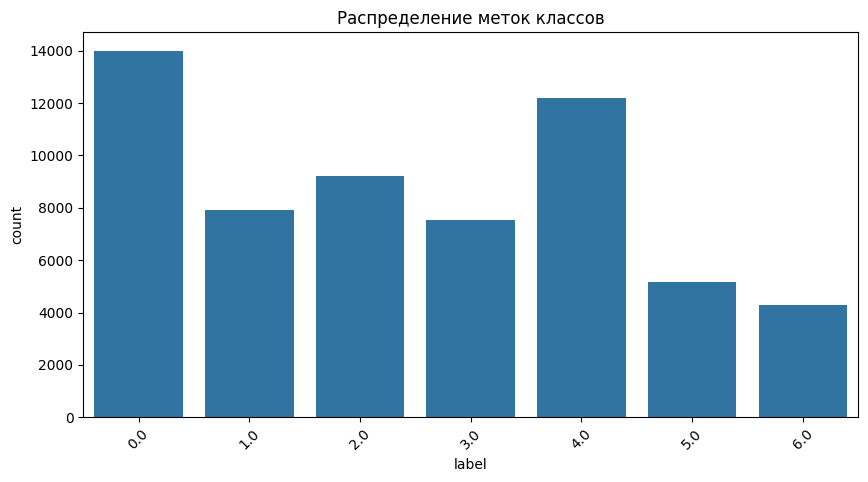


Распределение меток:
label
0.0    14001
1.0     7896
2.0     9196
3.0     7539
4.0    12188
5.0     5176
6.0     4278
Name: count, dtype: int64
3. АНАЛИЗ ТЕКСТОВЫХ ДАННЫХ:

Статистика длины текстов:
count    60274.000000
mean       150.934997
std         61.683465
min         22.000000
25%        109.000000
50%        148.000000
75%        190.000000
max        693.000000
Name: text_length, dtype: float64


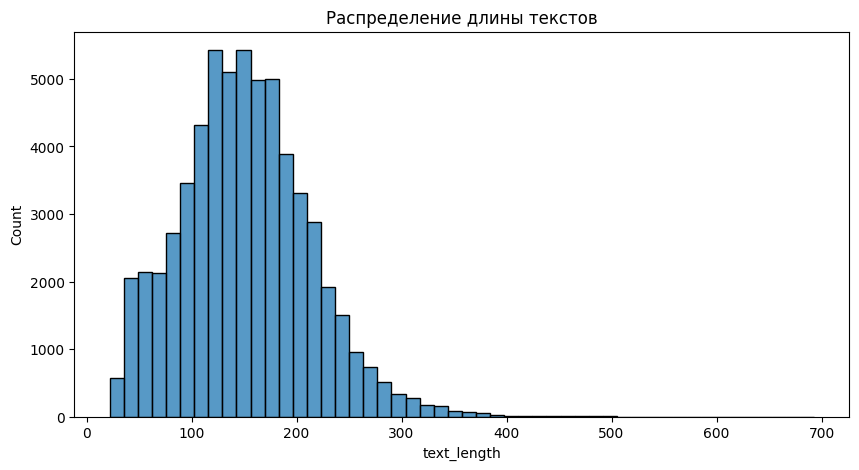

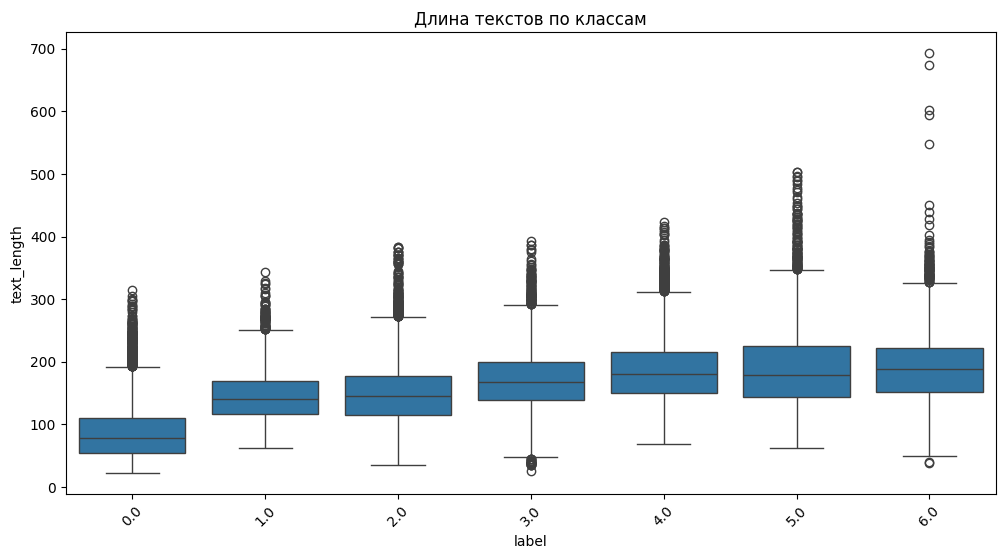


Примеры текстов по классам:

Метка 0.0:
1. decide to snuggle then do bed with the table lamp on....
2. i still had to look again on there!...

Метка 1.0:
1. Here at working going through SNMp trap log more hour and I am out of here did not get to study. I feel like I’m failing my responsibilities....
2. and sunburnt my mum wa out somewhere so i had to wait some people to get upstairs and fall asleep on their trampoline whilst sneaking in to sun you. I...

Метка 2.0:
1. She didnt get enough likes on her post and now she thinks shes a failure. This lack of validation makes her feel unworthy and sad....
2. time moved on by early marriage. they feel sick and uncomfortable. i am their guide. The changes make me feel lost and disconnected....

Метка 3.0:
1. some tone called ha cannot be exceptional to justify a three - hour recording time and this is rare. It generalizes the film as unworthy of its durati...
2. He can’t deny I feel a little unsure of myself when I can’t have our mile long, 

InvalidParameterError: The 'stop_words' parameter of CountVectorizer must be a str among {'english'}, an instance of 'list' or None. Got 'russian' instead.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

def check_cognitive_bias_dataset(df, text_column='text', label_column='label'):
    """
    Проверяет датасет с когнитивными искажениями на потенциальные проблемы

    Параметры:
    df - DataFrame с данными
    text_column - название столбца с текстом
    label_column - название столбца с метками
    """

    print("="*50)
    print("НАЧАЛО ПРОВЕРКИ ДАТАСЕТА КОГНИТИВНЫХ ИСКАЖЕНИЙ")
    print("="*50 + "\n")

    # 1. Базовая информация
    print("1. БАЗОВАЯ ИНФОРМАЦИЯ:")
    print(f"Всего записей: {len(df)}")
    print(f"Пример данных:\n{df.head(3)}\n")
    print(f"Типы данных:\n{df.dtypes}\n")
    print(f"Пропуски в данных:\n{df.isnull().sum()}\n")

    # 2. Анализ меток (labels)
    print("="*50)
    print("2. АНАЛИЗ МЕТОК:")
    unique_labels = df[label_column].unique()
    print(f"Уникальные метки: {sorted(unique_labels)}")

    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=label_column, order=sorted(unique_labels))
    plt.title("Распределение меток классов")
    plt.xticks(rotation=45)
    plt.show()

    label_dist = df[label_column].value_counts().sort_index()
    print("\nРаспределение меток:")
    print(label_dist)

    # Проверка на дисбаланс
    imbalance_ratio = label_dist.min() / label_dist.max()
    if imbalance_ratio < 0.3:
        print(f"\nВнимание: сильный дисбаланс классов (соотношение {imbalance_ratio:.2f})")

    # 3. Анализ текстовых данных
    print("="*50)
    print("3. АНАЛИЗ ТЕКСТОВЫХ ДАННЫХ:")

    # Длина текстов
    df['text_length'] = df[text_column].apply(len)
    print("\nСтатистика длины текстов:")
    print(df['text_length'].describe())

    plt.figure(figsize=(10, 5))
    sns.histplot(df['text_length'], bins=50)
    plt.title("Распределение длины текстов")
    plt.show()

    # Длина текстов по классам
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=label_column, y='text_length', order=sorted(unique_labels))
    plt.title("Длина текстов по классам")
    plt.xticks(rotation=45)
    plt.show()

    # Примеры текстов для каждого класса
    print("\nПримеры текстов по классам:")
    for label in sorted(unique_labels):
        sample_texts = df[df[label_column] == label][text_column].sample(min(2, len(df[df[label_column] == label])))
        print(f"\nМетка {label}:")
        for i, text in enumerate(sample_texts, 1):
            print(f"{i}. {text[:150]}...")

    # 4. Анализ слов по классам
    print("="*50)
    print("4. АНАЛИЗ СЛОВ ПО КЛАССАМ:")

    for label in sorted(unique_labels):
        texts = df[df[label_column] == label][text_column]
        if len(texts) > 0:  # проверка на случай отсутствия примеров класса
            vectorizer = CountVectorizer(stop_words='russian', max_features=15)
            X = vectorizer.fit_transform(texts)
            features = vectorizer.get_feature_names_out()

            print(f"\nТоп-15 слов для класса {label}:")
            print(", ".join(features))

    # 5. Проверка на утечку данных
    print("="*50)
    print("5. ПРОВЕРКА НА УТЕЧКУ ДАННЫХ:")

    # Проверяем, нет ли в тексте упоминаний меток
    possible_leakage = False
    for label in unique_labels:
        if str(label) in ['0', '1']:  # проверяем только для бинарных меток
            mask = df[text_column].str.contains(str(label), regex=False, case=False)
            if mask.any():
                print(f"Найдено {mask.sum()} текстов, содержащих метку '{label}' в тексте")
                possible_leakage = True

    if not possible_leakage:
        print("Явных признаков утечки данных не обнаружено")

    # 6. Рекомендации
    print("="*50)
    print("6. РЕКОМЕНДАЦИИ:")

    if len(df) < 1000:
        print("- Маленький размер датасета (<1000 записей) - рассмотрите сбор больше данных")

    if imbalance_ratio < 0.3:
        print("- Сильный дисбаланс классов - используйте методы балансировки (oversampling/undersampling)")

    if df['text_length'].std() > 300:
        print("- Большой разброс длины текстов - рассмотрите нормализацию длины текстов")

    print("\n" + "="*50)
    print("ПРОВЕРКА ЗАВЕРШЕНА")

# Пример использования с вашим кодом загрузки данных
def load_and_prepare_data(filepath):
    # Загрузка Excel-файла
    df = pd.read_excel(filepath, header=None, names=['raw_data'])  # Читаем как одну колонку

    # Разделяем по последней запятой
    df[['text', 'label']] = df['raw_data'].str.rsplit(',', n=1, expand=True)

    # Удаляем лишние пробелы
    df['text'] = df['text'].str.strip()
    df['label'] = df['label'].str.strip().astype(float)  # Преобразуем в число

    # Удаляем метку 7.0 (как в вашем коде)
    df = df[df['label'] != 7.0].copy()

    # Проверяем результат
    print("\nИнформация о загруженных данных:")
    print(df.head())
    print(f"\nВсего строк: {len(df)}")
    print(f"\nРаспределение классов:\n{df['label'].value_counts()}")
    print(f"\nЕсть ли пропуски:\n{df.isnull().sum()}")

    return df

# Загрузка данных и проверка
file_path = 'VIBOR.xlsx'
df = load_and_prepare_data(file_path)
check_cognitive_bias_dataset(df)

In [ ]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

# Разделяем данные на train и test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Инициализируем токенизатор DeBERTa v3
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

# Токенизация данных
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=165)

# Преобразуем DataFrame в Dataset (удобный формат для HuggingFace)
from datasets import Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)
import transformers
# Импортируем библиотеки
import numpy as np
import matplotlib.pyplot as plt
import os

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import DebertaV2Config, DebertaV2ForSequenceClassification

# Создаем конфигурацию с нужным количеством меток
config = DebertaV2Config.from_pretrained(
    "microsoft/deberta-v3-base",
    attention_probs_dropout_prob=0.2,
    hidden_dropout_prob=0.2,
    num_labels=7  # Передаем num_labels в конфигурацию
)

# Загружаем модель с использованием созданной конфигурации
model = DebertaV2ForSequenceClassification.from_pretrained("microsoft/deberta-v3-base", config=config)


                                            raw_data
0  I cannot believe I ate that cake. This overwhe...
1  man cannot swear i ate that stuff. The shame b...
2  I found Jason s observation very helpful in re...
3  i found jason s observation very helpful in re...
4  I feel so useless and do not know how to trust...
                                            raw_data  \
0  I cannot believe I ate that cake. This overwhe...   
1  man cannot swear i ate that stuff. The shame b...   
2  I found Jason s observation very helpful in re...   
3  i found jason s observation very helpful in re...   
4  I feel so useless and do not know how to trust...   

                                                text  label  
0  I cannot believe I ate that cake. This overwhe...    2.0  
1  man cannot swear i ate that stuff. The shame b...    2.0  
2  I found Jason s observation very helpful in re...    2.0  
3  i found jason s observation very helpful in re...    2.0  
4  I feel so useless and do not kno

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

...

Map:   0%|          | 0/48219 [00:00<?, ? examples/s]

Map:   0%|          | 0/12055 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def check_dataset(df, target_column, text_column=None):
    """
    Проверяет датасет на потенциальные проблемы

    Параметры:
    df - DataFrame с данными
    target_column - название столбца с целевой переменной
    text_column - название столбца с текстом (если есть)
    """

    print("="*50)
    print("НАЧАЛО ПРОВЕРКИ ДАТАСЕТА")
    print("="*50 + "\n")

    # 1. Проверка базовой информации
    print("1. БАЗОВАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ:")
    print(f"Всего записей: {len(df)}")
    print(f"Количество признаков: {len(df.columns)}")
    print("\nПервые 5 строк:")
    print(df.head())
    print("\nИнформация о типах данных и пропусках:")
    print(df.info())

    # 2. Проверка целевой переменной
    print("\n" + "="*50)
    print("2. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:")
    print(f"Уникальные классы: {df[target_column].unique()}")
    print("\nРаспределение классов:")
    class_dist = df[target_column].value_counts(normalize=True)
    print(class_dist)

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=target_column)
    plt.title("Распределение классов")
    plt.show()

    # 3. Проверка текстовых данных (если есть)
    if text_column:
        print("\n" + "="*50)
        print("3. АНАЛИЗ ТЕКСТОВЫХ ДАННЫХ:")

        # Длина текстов
        df['text_length'] = df[text_column].apply(len)
        print("\nСтатистика по длине текстов:")
        print(df['text_length'].describe())

        plt.figure(figsize=(8, 5))
        sns.histplot(df['text_length'], bins=50)
        plt.title("Распределение длины текстов")
        plt.show()

        # Примеры текстов
        print("\nПримеры текстов для каждого класса:")
        for class_name in df[target_column].unique():
            print(f"\nКласс: {class_name}")
            sample = df[df[target_column] == class_name][text_column].sample(2).values
            for i, text in enumerate(sample, 1):
                print(f"{i}. {text[:200]}...")

    # 4. Проверка на дубликаты
    print("\n" + "="*50)
    print("4. ПРОВЕРКА НА ДУБЛИКАТЫ:")
    duplicates = df.duplicated().sum()
    print(f"Найдено полных дубликатов: {duplicates}")

    if text_column:
        text_duplicates = df[text_column].duplicated().sum()
        print(f"Дубликатов текста: {text_duplicates}")

    # 5. Проверка на разметку (если есть несколько классов)
    if len(df[target_column].unique()) > 1:
        print("\n" + "="*50)
        print("5. ПРОВЕРКА КАЧЕСТВА РАЗМЕТКИ:")

        # Для текстовых данных можно проверить уникальные слова по классам
        if text_column:
            from sklearn.feature_extraction.text import CountVectorizer

            print("\nТоп слов по классам:")
            for class_name in df[target_column].unique():
                texts = df[df[target_column] == class_name][text_column]
                vectorizer = CountVectorizer(stop_words='english', max_features=20)
                X = vectorizer.fit_transform(texts)
                features = vectorizer.get_feature_names_out()

                print(f"\nКласс {class_name}:")
                print(", ".join(features))

    print("\n" + "="*50)
    print("РЕКОМЕНДАЦИИ:")

    if len(df) < 1000:
        print("- Маленький размер датасета (<1000 записей) - результаты могут быть ненадежными")

    if class_dist.min() / class_dist.max() < 0.3:
        print("- Сильный дисбаланс классов - рассмотрите методы балансировки")

    if duplicates > 0:
        print("- Найдены дубликаты - рекомендуется их удалить")

    if len(df[target_column].unique()) == 1:
        print("- В датасете только один класс - задача классификации невозможна")

    print("\n" + "="*50)
    print("ПРОВЕРКА ЗАВЕРШЕНА")

# Пример использования
# df = pd.read_csv('your_dataset.csv')
# check_dataset(df, target_column='bias_type', text_column='text')

In [ ]:
# Удаляем текущий torch и ставим заново
!pip uninstall torch torchvision torchaudio -y
!pip install torch==2.1.0 torchvision==0.16.0 torchaudio==2.1.0 --index-url https://download.pytorch.org/whl/cu118

In [ ]:
import torch
torch.cuda.empty_cache()  # Очистка кэша перед обучением

RuntimeError: CUDA error: device-side assert triggered
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
!pip install torch==2.0.1 transformers==4.30.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 130.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/173.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "f1_weighted": f1_score(labels, predictions, average="weighted")
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=100,
    logging_steps=10,
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    weight_decay=0.01,
    warmup_steps=200,
    save_strategy="steps",
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    fp16=True,
    gradient_accumulation_steps=2,
    report_to="all",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

trainer.train()

RuntimeError: CUDA error: device-side assert triggered
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
import pandas as pd
# Загрузка Excel-файла
df = pd.read_excel('aug_dataset.xlsx', header=None, names=['raw_data'])  # Читаем как одну колонку
print(df.head())
# Разделяем по последней запятой
df[['text', 'label']] = df['raw_data'].str.rsplit(',', n=1, expand=True)

# Удаляем лишние пробелы
df['text'] = df['text'].str.strip()
df['label'] = df['label'].str.strip().astype(float)  # Преобразуем в число


# Проверяем результат
print(df.head())
print(f"Всего строк: {len(df)}")
print(f"Распределение классов:\n{df['label'].value_counts()}")
print(f"Есть ли пропуски:\n{df.isnull().sum()}")

                                            raw_data
0              I cannot believe I ate that cake.,2.0
1             man cannot swear i ate that stuff.,2.0
2  I found Jason s observation very helpful in re...
3  i found jason s observation very helpful in re...
4  I feel so useless and do not know how to trust...
                                            raw_data  \
0              I cannot believe I ate that cake.,2.0   
1             man cannot swear i ate that stuff.,2.0   
2  I found Jason s observation very helpful in re...   
3  i found jason s observation very helpful in re...   
4  I feel so useless and do not know how to trust...   

                                                text  label  
0                  I cannot believe I ate that cake.    2.0  
1                 man cannot swear i ate that stuff.    2.0  
2  I found Jason s observation very helpful in re...    2.0  
3  i found jason s observation very helpful in re...    2.0  
4  I feel so useless and do not kno

In [ ]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

# Разделяем данные на train и test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Инициализируем токенизатор DeBERTa v3
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

# Токенизация данных
def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=165)

# Преобразуем DataFrame в Dataset (удобный формат для HuggingFace)
from datasets import Dataset
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.11/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/48219 [00:00<?, ? examples/s]

Map:   0%|          | 0/12055 [00:00<?, ? examples/s]

Средняя длина: 22.050320204399906, Максимум: 161


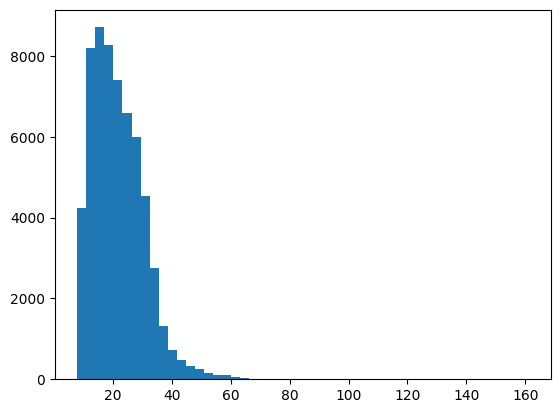

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
# Проверка распределения длин токенов
token_lengths = [len(x) for x in tokenizer(df['text'].tolist())['input_ids']]
print(f"Средняя длина: {np.mean(token_lengths)}, Максимум: {max(token_lengths)}")
plt.hist(token_lengths, bins=50)
plt.show()


In [ ]:
!pip install -U torch torchvision transformers

  Using cached transformers-4.52.3-py3-none-any.whl.metadata (40 kB)
  Using cached triton-3.3.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.5 kB)
Using cached triton-3.3.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (156.5 MB)
Using cached transformers-4.52.3-py3-none-any.whl (10.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 29.4 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.13.3
    Uninstalling tokenizers-0.13.3:
      Successfully uninstalled tokenizers-0.13.3
  Attempting uninstall: transformers
    Found existing installation: transformers 4.30.0
    Uninstalling transformers-4.30.0:
      Successfully uninstalled transformers-4.30.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.7.19 requires torch<2.7,>=1.10, but you have torch 2.7.0 

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
True


In [ ]:
import transformers
# Импортируем библиотеки
import numpy as np
import matplotlib.pyplot as plt
import os

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report
from transformers import DebertaV2Config, DebertaV2ForSequenceClassification

# Создаем конфигурацию с нужным количеством меток
config = DebertaV2Config.from_pretrained(
    "microsoft/deberta-v3-base",
    attention_probs_dropout_prob=0.2,
    hidden_dropout_prob=0.2,
    num_labels=7  # Передаем num_labels в конфигурацию
)

# Загружаем модель с использованием созданной конфигурации
model = DebertaV2ForSequenceClassification.from_pretrained("microsoft/deberta-v3-base", config=config)


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

In [ ]:
!pip install -U torch transformers datasets

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "f1_weighted": f1_score(labels, predictions, average="weighted")
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    eval_steps=100,
    logging_steps=10,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    warmup_steps=200,
    save_strategy="steps",
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    fp16=True,
    gradient_accumulation_steps=4,
    report_to="all",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rds7 (rds7-tpu) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
100,1.903400,1.864580,0.232269,0.053854,0.087560
200,1.759900,1.744513,0.303940,0.130077,0.201531
300,1.666900,1.635687,0.372957,0.242514,0.311872
400,1.440700,1.507986,0.440813,0.374078,0.398434
500,1.408700,1.420982,0.479884,0.459177,0.475133
600,1.400500,1.362559,0.500290,0.485320,0.497028
700,1.291200,1.366007,0.511904,0.483478,0.492278
800,1.152400,1.331352,0.515305,0.501742,0.507727
900,1.333600,1.310596,0.534633,0.532783,0.534085
1000,1.242400,1.322742,0.522937,0.515800,0.521084


TrainOutput(global_step=3770, training_loss=1.1762867113007158, metrics={'train_runtime': 5866.2451, 'train_samples_per_second': 41.099, 'train_steps_per_second': 0.643, 'total_flos': 2.044412690219955e+16, 'train_loss': 1.1762867113007158, 'epoch': 5.0})

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import softmax  # Add this import

# Получаем предсказания модели
test_predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(test_predictions.predictions, axis=1)
y_true = test_predictions.label_ids

# Вычисляем вероятности (для дальнейшего анализа)
y_probs = softmax(test_predictions.predictions, axis=1)

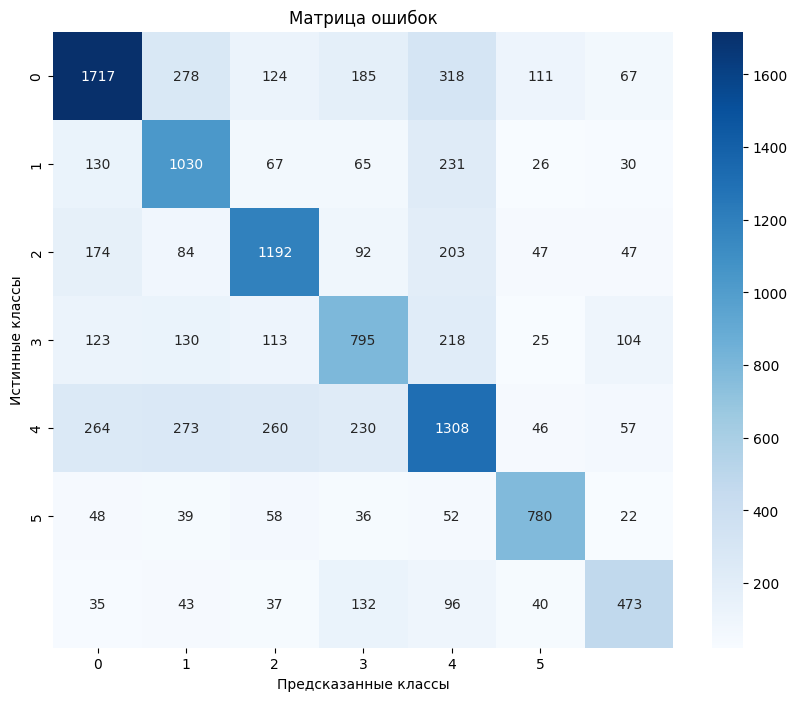

In [ ]:
# Создаем матрицу ошибок
cm = confusion_matrix(y_true, y_pred)

# Визуализируем
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(6), yticklabels=range(6))
plt.xlabel("Предсказанные классы")
plt.ylabel("Истинные классы")
plt.title("Матрица ошибок")
plt.show()

In [ ]:
import torch
from scipy.special import softmax

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Вычисляем вероятности с помощью softmax
    probabilities = softmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "f1_weighted": f1_score(labels, predictions, average="weighted"),
        "probabilities": probabilities  # Добавляем вероятности в возвращаемый словарь
    }

# После обучения модели можно получить предсказания с вероятностями
def get_predictions_with_probabilities(texts):
    # Токенизируем тексты
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=165, return_tensors="pt").to("cuda")

    # Получаем предсказания
    with torch.no_grad():
        outputs = model(**inputs)

    # Вычисляем вероятности
    logits = outputs.logits.cpu().numpy()
    probabilities = softmax(logits, axis=1)

    # Создаем DataFrame с результатами
    results = []
    for i, text in enumerate(texts):
        pred = np.argmax(probabilities[i])
        results.append({
            "text": text,
            "predicted_class": pred,
            "probabilities": probabilities[i],
            "confidence": probabilities[i][pred] * 100  # Уверенность в процентах
        })

    return pd.DataFrame(results)

# Пример использования:
sample_texts = ["My friend didn’t laugh at my joke—they must think I’m not funny.", "I’m anxious about the flight, so it must be dangerous", "She didn’t text me back—people always ignore me", "He didn't defend his diploma well, obviously he didn't do anything and he's lazy.", "They should have known how I felt—I shouldn’t have to explain.", "My headache must be a brain tumor."]
predictions_df = get_predictions_with_probabilities(sample_texts)

# Выводим результаты с вероятностями для каждого класса
for idx, row in predictions_df.iterrows():
    print(f"\nText: {row['text']}")
    print(f"Predicted class: {row['predicted_class']}")
    print(f"Confidence: {row['confidence']:.2f}%")
    print("Class probabilities:")
    for class_idx, prob in enumerate(row['probabilities']):
        print(f"  Class {class_idx}: {prob*100:.2f}%")


Text: My friend didn’t laugh at my joke—they must think I’m not funny.
Predicted class: 3
Confidence: 99.85%
Class probabilities:
  Class 0: 0.01%
  Class 1: 0.03%
  Class 2: 0.01%
  Class 3: 99.85%
  Class 4: 0.04%
  Class 5: 0.03%
  Class 6: 0.02%

Text: I’m anxious about the flight, so it must be dangerous
Predicted class: 3
Confidence: 96.31%
Class probabilities:
  Class 0: 0.19%
  Class 1: 0.10%
  Class 2: 2.84%
  Class 3: 96.31%
  Class 4: 0.04%
  Class 5: 0.07%
  Class 6: 0.45%

Text: She didn’t text me back—people always ignore me
Predicted class: 3
Confidence: 99.95%
Class probabilities:
  Class 0: 0.01%
  Class 1: 0.01%
  Class 2: 0.01%
  Class 3: 99.95%
  Class 4: 0.01%
  Class 5: 0.00%
  Class 6: 0.02%

Text: He didn't defend his diploma well, obviously he didn't do anything and he's lazy.
Predicted class: 3
Confidence: 99.56%
Class probabilities:
  Class 0: 0.05%
  Class 1: 0.01%
  Class 2: 0.03%
  Class 3: 99.56%
  Class 4: 0.04%
  Class 5: 0.00%
  Class 6: 0.31%

Text: 

In [ ]:
import pandas as pd
import numpy as np
import torch
from scipy.special import softmax
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model_on_excel(file_path):
    # Читаем данные вашим способом
    df = pd.read_excel(file_path, header=None, names=['raw_data'])

    # Разделяем по последней запятой
    df[['text', 'label']] = df['raw_data'].str.rsplit(',', n=1, expand=True)

    # Преобразуем метки в числовой формат
    df['label'] = df['label'].astype(float).astype(int)  # Сначала float, потом int для случаев типа 1.0

    texts = df['text'].tolist()
    true_labels = df['label'].tolist()

    # Получаем предсказания
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=165, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits.cpu().numpy()
    probabilities = softmax(logits, axis=1)
    predictions = np.argmax(logits, axis=-1)

    # Вычисляем метрики
    metrics = {
        "accuracy": accuracy_score(true_labels, predictions),
        "f1_macro": f1_score(true_labels, predictions, average="macro"),
        "f1_weighted": f1_score(true_labels, predictions, average="weighted")
    }

    # Создаем подробный отчет
    results_df = pd.DataFrame({
        "text": texts,
        "true_label": true_labels,
        "predicted_label": predictions,
        "confidence": [prob[pred]*100 for prob, pred in zip(probabilities, predictions)]
    })

    # Добавляем вероятности по всем классам
    for i in range(probabilities.shape[1]):
        results_df[f"class_{i}_prob"] = probabilities[:, i]

    return metrics, results_df

# Пример использования:
file_path = "test_dataset.xlsx"  # Ваш файл в указанном формате
metrics, detailed_results = evaluate_model_on_excel(file_path)

print("\nEvaluation Metrics:")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 Macro: {metrics['f1_macro']:.4f}")
print(f"F1 Weighted: {metrics['f1_weighted']:.4f}")

# Сохраняем результаты
detailed_results.to_excel("model_predictions_detailed.xlsx", index=False)
print("\nDetailed predictions saved to 'model_predictions_detailed.xlsx'")

# Выводим примеры предсказаний
print("\nSample predictions:")
for i, row in detailed_results.head(3).iterrows():
    print(f"\nText: {row['text']}")
    print(f"True label: {row['true_label']}")
    print(f"Predicted: {row['predicted_label']} (confidence: {row['confidence']:.1f}%)")
    print("Probabilities:", [f"{p:.3f}" for p in row.filter(regex='class_\d+_prob')])


Evaluation Metrics:
Accuracy: 0.3810
F1 Macro: 0.4286
F1 Weighted: 0.4286

Detailed predictions saved to 'model_predictions_detailed.xlsx'

Sample predictions:

Text: We went to the club yesterday, but no one liked it. Probably because I was there—I ruin everything.
True label: 1
Predicted: 6 (confidence: 73.2%)
Probabilities: ['0.011', '0.004', '0.003', '0.216', '0.030', '0.003', '0.732']

Text: My friend hasn't texted me in a long time; most likely, I behaved badly in our communication.
True label: 1
Predicted: 6 (confidence: 92.3%)
Probabilities: ['0.004', '0.007', '0.003', '0.040', '0.015', '0.007', '0.923']

Text: Today before the flight, I have a strange feeling—we’re definitely going to crash.
True label: 2
Predicted: 2 (confidence: 79.3%)
Probabilities: ['0.009', '0.002', '0.793', '0.057', '0.129', '0.003', '0.007']


In [ ]:
import pandas as pd
import numpy as np
import torch
from scipy.special import softmax
from sklearn.metrics import accuracy_score, f1_score

def evaluate_model_on_excel(file_path, sheet_name=0):
    # Загружаем данные из Excel
    df = pd.read_excel(file_path, sheet_name=sheet_name)

    # Проверяем формат данных (должен быть текст в одной колонке и метка в другой)
    texts = df.iloc[:, 0].tolist()  # Первая колонка - тексты
    true_labels = df.iloc[:, 1].tolist()  # Вторая колонка - метки

    # Получаем предсказания
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=165, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits.cpu().numpy()
    probabilities = softmax(logits, axis=1)
    predictions = np.argmax(logits, axis=-1)

    # Вычисляем метрики
    metrics = {
        "accuracy": accuracy_score(true_labels, predictions),
        "f1_macro": f1_score(true_labels, predictions, average="macro"),
        "f1_weighted": f1_score(true_labels, predictions, average="weighted")
    }

    # Создаем подробный отчет с предсказаниями
    results_df = pd.DataFrame({
        "text": texts,
        "true_label": true_labels,
        "predicted_label": predictions,
        "confidence": [prob[pred]*100 for prob, pred in zip(probabilities, predictions)]
    })

    # Добавляем вероятности по всем классам
    for i in range(probabilities.shape[1]):
        results_df[f"class_{i}_prob"] = probabilities[:, i]

    return metrics, results_df

# Пример использования:
file_path = "test_dataset.xlsx"  # Путь к вашему Excel-файлу
metrics, detailed_results = evaluate_model_on_excel(file_path)

print("\nEvaluation Metrics:")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"F1 Macro: {metrics['f1_macro']:.4f}")
print(f"F1 Weighted: {metrics['f1_weighted']:.4f}")

# Сохраняем подробные результаты в новый Excel-файл
detailed_results.to_excel("model_predictions.xlsx", index=False)
print("\nDetailed predictions saved to 'model_predictions.xlsx'")

IndexError: single positional indexer is out-of-bounds

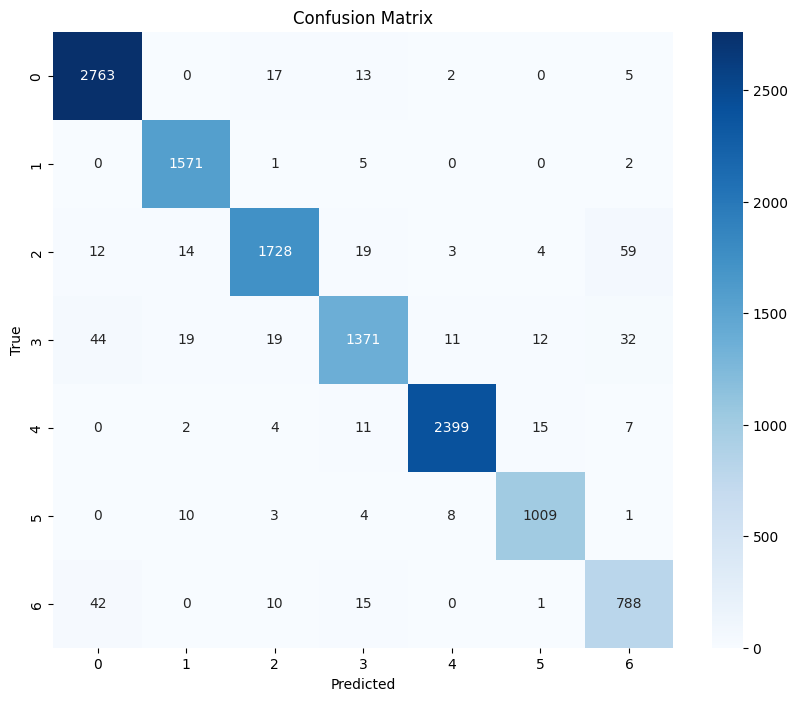

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# После получения предсказаний:
predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

plot_confusion_matrix(y_true, y_pred, classes=[str(i) for i in range(7)])

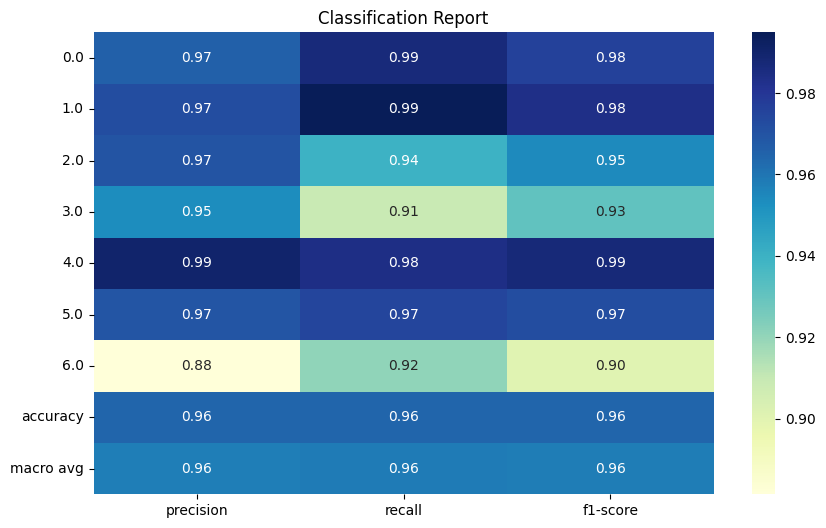

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

def plot_classification_report(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose().iloc[:-1, :3]

    plt.figure(figsize=(10, 6))
    sns.heatmap(df_report, annot=True, cmap='YlGnBu', fmt='.2f')
    plt.title('Classification Report')
    plt.show()

plot_classification_report(y_true, y_pred)

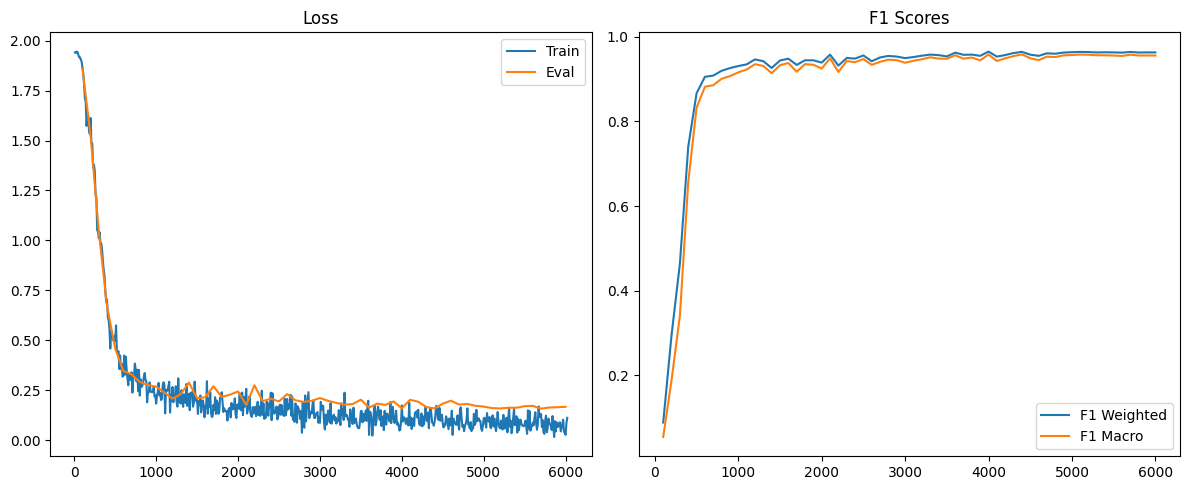

In [ ]:
import matplotlib.pyplot as plt

def plot_metrics(trainer):
    metrics = trainer.state.log_history
    train_metrics = [x for x in metrics if 'loss' in x]
    eval_metrics = [x for x in metrics if 'eval_loss' in x]

    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot([x['step'] for x in train_metrics], [x['loss'] for x in train_metrics], label='Train')
    plt.plot([x['step'] for x in eval_metrics], [x['eval_loss'] for x in eval_metrics], label='Eval')
    plt.title('Loss')
    plt.legend()

    # F1 Score
    plt.subplot(1, 2, 2)
    plt.plot([x['step'] for x in eval_metrics], [x['eval_f1_weighted'] for x in eval_metrics], label='F1 Weighted')
    plt.plot([x['step'] for x in eval_metrics], [x['eval_f1_macro'] for x in eval_metrics], label='F1 Macro')
    plt.title('F1 Scores')
    plt.legend()

    plt.tight_layout()
    plt.show()

# После обучения:
plot_metrics(trainer)

In [ ]:
import pandas as pd
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                            precision_recall_curve, average_precision_score,
                            roc_auc_score, precision_score, recall_score)
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                         TrainingArguments, Trainer, DebertaV2Config,
                         DebertaV2ForSequenceClassification, EarlyStoppingCallback)
from torch import nn
import nltk
from nltk.corpus import stopwords

# 1. Инициализация и загрузка данных
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

df = pd.read_excel('VIBOR.xlsx', header=None, names=['raw_data'])
df[['text', 'label']] = df['raw_data'].str.rsplit(',', n=1, expand=True)
df['text'] = df['text'].str.strip()
df['label'] = df['label'].str.strip().astype(float)

# 2. Расширенная очистка текста
def clean_text(text):
    # Удаление специфичных паттернов (настройте под ваш датасет)
    text = re.sub(r'\b(?:слово1|слово2|слово3)\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = ' '.join([word for word in text.split() if word.lower() not in stop_words])
    return text.strip()

df['cleaned_text'] = df['text'].apply(clean_text)

# 3. Подготовка модели с улучшенной конфигурацией
config = DebertaV2Config.from_pretrained(
    "microsoft/deberta-v3-base",
    attention_probs_dropout_prob=0.3,
    hidden_dropout_prob=0.3,
    num_labels=7,
    hidden_act="gelu",
    intermediate_size=2048,
    num_attention_heads=12
)

model = DebertaV2ForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-base",
    config=config
)

# 4. Кастомный токенизатор с обработкой очищенного текста
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")

def tokenize_function(examples):
    return tokenizer(
        examples["cleaned_text"],
        padding="max_length",
        truncation=True,
        max_length=165,
        add_special_tokens=True,
        return_attention_mask=True
    )

# 5. Кастомный Trainer с взвешенной функцией потерь
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        weights = torch.tensor([1.0, 1.5, 1.5, 2.0, 1.2, 1.7, 1.3]).to(logits.device)
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# 6. Расширенные метрики
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Многоклассовые метрики
    metrics = {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(labels, predictions, average="macro"),
        "f1_weighted": f1_score(labels, predictions, average="weighted"),
        "precision_macro": precision_score(labels, predictions, average="macro"),
        "recall_macro": recall_score(labels, predictions, average="macro")
    }

    # Дополнительные метрики для бинарного случая (если нужно)
    if config.num_labels == 2:
        metrics.update({
            "average_precision": average_precision_score(labels, logits[:, 1]),
            "roc_auc": roc_auc_score(labels, logits[:, 1])
        })
    else:
        metrics["roc_auc_ovo"] = roc_auc_score(labels, logits, multi_class="ovo")

    return metrics

# 7. Кросс-валидация с улучшенными параметрами обучения
kf = KFold(n_splits=3, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
    print(f"\n=== Fold {fold + 1} ===")

    train_fold = df.iloc[train_idx]
    val_fold = df.iloc[val_idx]

    train_dataset = Dataset.from_pandas(train_fold)
    val_dataset = Dataset.from_pandas(val_fold)

    tokenized_train = train_dataset.map(tokenize_function, batched=True)
    tokenized_val = val_dataset.map(tokenize_function, batched=True)

    training_args = TrainingArguments(
        output_dir=f"./results_fold_{fold}",
        evaluation_strategy="steps",
        eval_steps=100,
        logging_strategy="steps",
        logging_steps=50,
        learning_rate=3e-6,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=5,
        weight_decay=0.05,
        warmup_ratio=0.1,
        save_strategy="steps",
        save_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="f1_weighted",
        greater_is_better=True,
        fp16=True,
        gradient_accumulation_steps=4,
        report_to="none",
        seed=42
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()
    trainer.save_model(f"./model_fold_{fold}")

    # 8. Анализ важности признаков для примера
    if fold == 0:  # Пример для первого фолда
        sample_text = val_fold.iloc[0]['cleaned_text']
        inputs = tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=165)
        with torch.no_grad():
            outputs = model(**inputs, output_attentions=True)

        attentions = outputs.attentions[-1].mean(dim=1).squeeze().mean(dim=0)
        tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

        plt.figure(figsize=(12, 6))
        plt.bar(range(len(tokens)), attentions.detach().numpy())
        plt.xticks(range(len(tokens)), tokens, rotation=90)
        plt.title(f"Attention weights for sample (Fold {fold})")
        plt.savefig(f"attention_weights_fold_{fold}.png")
        plt.close()

# 9. Финальная оценка на тестовом наборе (если есть отдельный тестовый набор)
# Для примера используем последний валидационный набор
test_results = trainer.evaluate(tokenized_val)
print("\n=== Final Test Results ===")
print(f"Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"F1 Weighted: {test_results['eval_f1_weighted']:.4f}")
print(f"ROC AUC OVO: {test_results['eval_roc_auc_ovo']:.4f}")

# 10. Сохранение лучшей модели
best_model_path = "./best_model"
trainer.save_model(best_model_path)
tokenizer.save_pretrained(best_model_path)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

RuntimeError: Error(s) in loading state_dict for Linear:
	size mismatch for weight: copying a param with shape torch.Size([3072, 768]) from checkpoint, the shape in current model is torch.Size([2048, 768]).